In [1]:
%pip install -q vtk trimesh nibabel scikit-image tqdm torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 13.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.2 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, gzip, json, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import vtk, trimesh
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool, AttentionalAggregation
from torch.utils.data import Dataset

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count() if DEVICE.type == 'cuda' else 0
print(f'Device: {DEVICE}  |  GPUs: {NUM_GPUS}')

Device: cuda  |  GPUs: 2


In [3]:
SSM_DIR = 'Statistical-Shape-Model'
if not os.path.exists(SSM_DIR):
    os.system('git clone --quiet https://github.com/UK-Digital-Heart-Project/Statistical-Shape-Model.git')
    print('SSM repo cloned')
else:
    print('SSM repo present')

for f in ['LV_ED_mean.vtk', 'LV_ED_pc_100_modes.csv.gz', 'LV_ED_var_100_modes.csv.gz']:
    p = os.path.join(SSM_DIR, f)
    print(f'  {"OK" if os.path.exists(p) else "MISSING"}  {f}')

SSM repo cloned
  OK  LV_ED_mean.vtk
  OK  LV_ED_pc_100_modes.csv.gz
  OK  LV_ED_var_100_modes.csv.gz


In [4]:
from vtk.util import numpy_support

def load_vtk_points(vtk_path):
    reader = vtk.vtkPolyDataReader()
    reader.SetFileName(vtk_path)
    reader.Update()
    polydata = reader.GetOutput()
    points = np.array([polydata.GetPoint(i) for i in range(polydata.GetNumberOfPoints())])
    return points, polydata

mean_vtk_path = os.path.join(SSM_DIR, 'LV_ED_mean.vtk')
pc_path       = os.path.join(SSM_DIR, 'LV_ED_pc_100_modes.csv.gz')
var_path      = os.path.join(SSM_DIR, 'LV_ED_var_100_modes.csv.gz')

mean_points, mean_polydata = load_vtk_points(mean_vtk_path)

with gzip.open(pc_path, 'rt') as f:
    pc = np.loadtxt(f, delimiter=',')

with gzip.open(var_path, 'rt') as f:
    lambdas = np.loadtxt(f, delimiter=',')

print(f'Mean shape : {mean_points.shape}')
print(f'PC matrix  : {pc.shape}')
print(f'Eigenvalues: {lambdas.shape}')

Mean shape : (22043, 3)
PC matrix  : (66129, 100)
Eigenvalues: (100,)


## Cell 1b — Diagnose mesh, build fast quality checker, calibrate bounds

Three critical fixes vs. original:
1. Use **`vtkTriangleFilter`** to triangulate (handles any polygon, not just tri/quad)  
2. Use **trimesh** with `fix_normals` for robust volume (no winding assumption)  
3. Calibrate SA bounds from **measured mean-shape SA** rather than a hard-coded mm² formula

In [5]:
# ── 1. Inspect cell types ────────────────────────────────────────────────────
n_cells = mean_polydata.GetNumberOfCells()
sizes = {}
for i in range(min(n_cells, 5000)):
    n = mean_polydata.GetCell(i).GetNumberOfPoints()
    sizes[n] = sizes.get(n, 0) + 1
print(f'Cells: {n_cells}   size distribution (first 5k): {sizes}')
print()

# ── 2. VTK reference (ground truth for this mesh family) ────────────────────
nrm = vtk.vtkPolyDataNormals()
nrm.SetInputData(mean_polydata)
nrm.ConsistencyOn(); nrm.AutoOrientNormalsOn(); nrm.SplittingOff()
nrm.Update()
mp = vtk.vtkMassProperties()
mp.SetInputConnection(nrm.GetOutputPort())
mp.Update()
VTK_VOL = abs(mp.GetVolume())
VTK_SA  = mp.GetSurfaceArea()
print(f'VTK Volume : {VTK_VOL:,.1f}  SA : {VTK_SA:,.1f}')

# ── 3. Triangulate once via vtkTriangleFilter — handles any polygon type ────
tri_filt = vtk.vtkTriangleFilter()
tri_filt.SetInputData(mean_polydata)
tri_filt.Update()
tri_poly = tri_filt.GetOutput()

TEMPLATE_FACES = np.array([
    [tri_poly.GetCell(i).GetPointId(j) for j in range(3)]
    for i in range(tri_poly.GetNumberOfCells())
    if tri_poly.GetCell(i).GetNumberOfPoints() == 3
], dtype=np.int32)

print(f'TEMPLATE_FACES : {TEMPLATE_FACES.shape}')
assert len(TEMPLATE_FACES) > 0, 'ERROR: face extraction returned nothing!'

# ── 4. Trimesh diagnostic (only for sanity) ──────────────────────────────────
tm_mean = trimesh.Trimesh(vertices=mean_points, faces=TEMPLATE_FACES, process=False)
trimesh.repair.fix_normals(tm_mean)
TM_VOL = abs(tm_mean.volume)
TM_SA  = tm_mean.area
VOL_RATIO = TM_VOL / max(VTK_VOL, 1e-8)
print(f'Trimesh Volume : {TM_VOL:,.1f}  SA : {TM_SA:,.1f}')
print(f'Vol ratio (trimesh/VTK): {VOL_RATIO:.4f}')

# ── 5. Exact VTK mass properties (robust but slower) ─────────────────────────
def vtk_massprops_from_points(points):
    poly = vtk.vtkPolyData()
    poly.DeepCopy(tri_poly)
    vp = vtk.vtkPoints()
    vp.SetData(numpy_support.numpy_to_vtk(points.astype(np.float64), deep=True))
    poly.SetPoints(vp)

    nrm_loc = vtk.vtkPolyDataNormals()
    nrm_loc.SetInputData(poly)
    nrm_loc.ConsistencyOn(); nrm_loc.AutoOrientNormalsOn(); nrm_loc.SplittingOff()
    nrm_loc.Update()

    mp_loc = vtk.vtkMassProperties()
    mp_loc.SetInputConnection(nrm_loc.GetOutputPort())
    mp_loc.Update()
    return abs(mp_loc.GetVolume()), mp_loc.GetSurfaceArea()


# ── 6. Ultra-fast numpy proxy metrics (vectorized over triangles) ────────────
def _mesh_metrics_numpy_raw(points):
    """Raw mesh metrics from triangle soup (very fast)."""
    tri = points[TEMPLATE_FACES]  # (F, 3, 3)
    v0, v1, v2 = tri[:, 0], tri[:, 1], tri[:, 2]
    area = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0), axis=1).sum()
    vol  = abs(np.einsum('ij,ij->i', v0, np.cross(v1, v2)).sum()) / 6.0
    return float(vol), float(area)


# Calibrate proxy to exact backend on mean shape
RAW_VOL0, RAW_SA0 = _mesh_metrics_numpy_raw(mean_points)
CALIB_VOL, CALIB_SA = VTK_VOL, VTK_SA
VOL_CORR = CALIB_VOL / max(RAW_VOL0, 1e-8)
SA_CORR  = CALIB_SA  / max(RAW_SA0, 1e-8)

print(f'Proxy calibration factors: vol×{VOL_CORR:.4f}  sa×{SA_CORR:.4f}')


def compute_mesh_quality_proxy(points):
    """Fast proxy (used in the generation loop)."""
    vol_raw, sa_raw = _mesh_metrics_numpy_raw(points)
    vol = vol_raw * VOL_CORR
    sa  = sa_raw * SA_CORR
    psi = (np.pi**(1/3)) * ((6 * vol)**(2/3)) / sa if sa > 0 else 0.0
    return vol, sa, psi


def compute_mesh_quality_fast(points):
    """Exact quality (VTK). Use sparsely because it is expensive."""
    vol, sa = vtk_massprops_from_points(points)
    psi = (np.pi**(1/3)) * ((6 * vol)**(2/3)) / sa if sa > 0 else 0.0
    return vol, sa, psi


# ── 7. Precompute sparse smoothing operator (fast Laplacian smoothing) ───────
from scipy import sparse

N_VERT = mean_points.shape[0]
_i = np.concatenate([
    TEMPLATE_FACES[:, 0], TEMPLATE_FACES[:, 1], TEMPLATE_FACES[:, 2],
    TEMPLATE_FACES[:, 0], TEMPLATE_FACES[:, 1], TEMPLATE_FACES[:, 2],
])
_j = np.concatenate([
    TEMPLATE_FACES[:, 1], TEMPLATE_FACES[:, 2], TEMPLATE_FACES[:, 0],
    TEMPLATE_FACES[:, 2], TEMPLATE_FACES[:, 0], TEMPLATE_FACES[:, 1],
])
_data = np.ones(len(_i), dtype=np.float64)
A = sparse.coo_matrix((_data, (_i, _j)), shape=(N_VERT, N_VERT)).tocsr()
A.data[:] = 1.0
A = A.maximum(A.T)

deg = np.asarray(A.sum(axis=1)).ravel()
deg[deg == 0] = 1.0
Dinv = sparse.diags(1.0 / deg)
W = Dinv @ A  # row-normalized neighbor averaging


def laplacian_smooth(vertices, faces=None, iterations=3, lam=0.5):
    """
    Fast Laplacian smoothing using sparse matrix multiplication.
    ~100x faster than Python vertex loops on this mesh size.
    """
    _ = faces  # topology is fixed by TEMPLATE_FACES/W
    v = vertices.astype(np.float64, copy=True)
    for _ in range(iterations):
        v = v + lam * (W @ v - v)
    return v.astype(np.float32)


def check_apex_base_quality(vertices, faces, z_percentile=10, max_normal_var=1.8):
    """
    Numpy-only apex/base roughness check.
    Much faster than trimesh construction inside the main generation loop.
    """
    tri = vertices[faces]
    v0, v1, v2 = tri[:, 0], tri[:, 1], tri[:, 2]
    fn = np.cross(v1 - v0, v2 - v0)
    n = np.linalg.norm(fn, axis=1, keepdims=True)
    n[n < 1e-12] = 1.0
    fn = fn / n
    fc = tri.mean(axis=1)
    z = fc[:, 2]

    z_lo = np.percentile(z, z_percentile)
    z_hi = np.percentile(z, 100 - z_percentile)

    for region_mask in [z <= z_lo, z >= z_hi]:
        if region_mask.sum() < 3:
            continue
        normals_region = fn[region_mask]
        normal_var = normals_region.var(axis=0).sum()
        if normal_var > max_normal_var:
            return False
    return True


# ── 8. Verify exact + proxy on mean shape ────────────────────────────────────
v_exact, s_exact, p_exact = compute_mesh_quality_fast(mean_points)
v_proxy, s_proxy, p_proxy = compute_mesh_quality_proxy(mean_points)

print('\n✅ Helper functions ready')
print(f'Exact  mean shape: vol={v_exact:.1f}  sa={s_exact:.1f}  psi={p_exact:.4f}')
print(f'Proxy  mean shape: vol={v_proxy:.1f}  sa={s_proxy:.1f}  psi={p_proxy:.4f}')
print(f'Exact vol err vs VTK: {abs(v_exact - VTK_VOL)/max(VTK_VOL,1e-8)*100:.2f}%')
print(f'Proxy vol err vs VTK: {abs(v_proxy - VTK_VOL)/max(VTK_VOL,1e-8)*100:.2f}%')

Cells: 43840   size distribution (first 5k): {3: 5000}

VTK Volume : 393,562.2  SA : 32,912.5
TEMPLATE_FACES : (43840, 3)
Trimesh Volume : 101,351.1  SA : 32,912.5
Vol ratio (trimesh/VTK): 0.2575
Proxy calibration factors: vol×3.8832  sa×1.0000

✅ Helper functions ready
Exact  mean shape: vol=393562.2  sa=32912.5  psi=0.7891
Proxy  mean shape: vol=393562.2  sa=32912.5  psi=0.7891
Exact vol err vs VTK: 0.00%
Proxy vol err vs VTK: 0.00%


In [6]:
# ── Calibrate bounds from measured mean-shape values ─────────────────────────
REFERENCE_MEAN_VOL_ML = 142.0   # Bai et al. 2015 UKBB
REFERENCE_MEAN_SA_CM2 = 100.0   # approximate healthy LV surface area

SCALE_VOL = CALIB_VOL / REFERENCE_MEAN_VOL_ML   # native³ / mL
SCALE_SA  = CALIB_SA  / REFERENCE_MEAN_SA_CM2   # native² / cm²

print(f'SCALE_VOL : {SCALE_VOL:.2f}  native³/mL')
print(f'SCALE_SA  : {SCALE_SA:.2f}  native²/cm²')
print(f'Linear scale : {SCALE_VOL**(1/3):.3f}  (1.0 = mm)')

VOL_MIN_ML, VOL_MAX_ML = 40.0, 350.0
SA_MIN_CM2, SA_MAX_CM2 = 40.0, 400.0

# Mean shape metrics (must be computed before setting psi threshold)
v0, s0, p0 = compute_mesh_quality_fast(mean_points)

# IMPORTANT:
# UK Biobank LV endocardial SSM can have mean-shape sphericity around ~0.31–0.33.
# Using 0.40 would wrongly reject the template itself.
# We keep a conservative floor that still removes extreme artefacts.
SPHER_MIN = min(0.40, max(0.30, p0 - 0.01))

LV_VOL_MIN = VOL_MIN_ML * SCALE_VOL
LV_VOL_MAX = VOL_MAX_ML * SCALE_VOL
LV_SA_MIN  = SA_MIN_CM2 * SCALE_SA
LV_SA_MAX  = SA_MAX_CM2 * SCALE_SA

print(f'\nBounds (native units):')
print(f'  Vol  : [{LV_VOL_MIN:.0f}, {LV_VOL_MAX:.0f}]  = [{VOL_MIN_ML}, {VOL_MAX_ML}] mL')
print(f'  SA   : [{LV_SA_MIN:.0f},  {LV_SA_MAX:.0f}]  = [{SA_MIN_CM2}, {SA_MAX_CM2}] cm²')
print(f'  psi  : >= {SPHER_MIN:.3f}  (auto-calibrated from mean shape psi={p0:.3f})')
print()

# Mean shape MUST pass calibration bounds
v_ok  = LV_VOL_MIN <= v0 <= LV_VOL_MAX
sa_ok = LV_SA_MIN  <= s0 <= LV_SA_MAX
p_ok  = p0 >= SPHER_MIN
print(f'Mean shape — vol={v0/SCALE_VOL:.1f} mL {"OK" if v_ok else "FAIL"}  '
      f'sa={s0/SCALE_SA:.1f} cm² {"OK" if sa_ok else "FAIL"}  '
      f'psi={p0:.3f} {"OK" if p_ok else "FAIL"}')
assert v_ok and sa_ok and p_ok, 'Mean shape fails its own bounds — calibration error!'

SCALE_VOL : 2771.56  native³/mL
SCALE_SA  : 329.13  native²/cm²
Linear scale : 14.047  (1.0 = mm)

Bounds (native units):
  Vol  : [110863, 970048]  = [40.0, 350.0] mL
  SA   : [13165,  131650]  = [40.0, 400.0] cm²
  psi  : >= 0.400  (auto-calibrated from mean shape psi=0.789)

Mean shape — vol=142.0 mL OK  sa=100.0 cm² OK  psi=0.789 OK


## 2. SSM Shape-Space Analysis & Sampling

In [7]:
from scipy.stats import chi2 as chi2_dist

total_var = lambdas.sum()
cum_var   = np.cumsum(lambdas) / total_var
k99 = int(np.searchsorted(cum_var, 0.99)) + 1

NUM_MODES_EFF = k99
sigmas_eff    = np.sqrt(lambdas[:NUM_MODES_EFF])
MAHAL_ALPHA   = 0.99
SIGMA_CLIP    = 3.0
mahal_thresh  = chi2_dist.ppf(MAHAL_ALPHA, df=NUM_MODES_EFF)

print(f'Effective modes : {NUM_MODES_EFF}')
print(f'Mahal threshold : {mahal_thresh:.2f}')

Effective modes : 32
Mahal threshold : 53.49


## 3. DIAGNOSTIC — check a few candidates before full run

In [8]:
def mesh_points_from_latent(b_full):
    return (mean_points.flatten() + pc @ b_full).reshape(-1, 3)

def make_vtk_poly(pts, template_polydata):
    new_poly = vtk.vtkPolyData()
    new_poly.DeepCopy(template_polydata)
    vp = vtk.vtkPoints()
    vp.SetData(numpy_support.numpy_to_vtk(pts))
    new_poly.SetPoints(vp)
    return new_poly

def sample_latent_batch(batch_size):
    raw   = np.random.normal(0.0, sigmas_eff, size=(batch_size * 2, NUM_MODES_EFF))
    b_std = raw / sigmas_eff
    d2    = np.sum(b_std ** 2, axis=1)
    ok    = (np.all(np.abs(b_std) <= SIGMA_CLIP, axis=1) & (d2 <= mahal_thresh))
    valid = raw[ok]
    padded = np.zeros((len(valid), 100))
    padded[:, :NUM_MODES_EFF] = valid
    return padded

# Sample 8 candidates and print their metrics vs bounds
test_batch = sample_latent_batch(4)
print(f'Sampled {len(test_batch)} candidates for diagnostic\n')
print(f'{"#":<3} {"vol_ml":>8} {"vol_ok":>7} {"sa_cm2":>8} {"sa_ok":>7} {"psi":>7} {"psi_ok":>7} {"ACCEPT":>8}')
print('-' * 62)
for i, b in enumerate(test_batch[:8]):
    pts = mesh_points_from_latent(b)
    vol, sa, psi = compute_mesh_quality_fast(pts)
    vol_ml = vol / SCALE_VOL
    sa_cm2 = sa  / SCALE_SA
    v_ok   = LV_VOL_MIN <= vol <= LV_VOL_MAX
    s_ok   = LV_SA_MIN  <= sa  <= LV_SA_MAX
    p_ok   = psi >= SPHER_MIN
    acc    = v_ok and s_ok and p_ok
    print(f'{i:<3} {vol_ml:>8.1f} {str(v_ok):>7} {sa_cm2:>8.1f} {str(s_ok):>7} {psi:>7.3f} {str(p_ok):>7} {"YES" if acc else "NO":>8}')

print()
print(f'Expected vol range  : {VOL_MIN_ML}–{VOL_MAX_ML} mL')
print(f'Expected SA range   : {SA_MIN_CM2}–{SA_MAX_CM2} cm²')
print(f'Expected psi min    : {SPHER_MIN}')

Sampled 7 candidates for diagnostic

#     vol_ml  vol_ok   sa_cm2   sa_ok     psi  psi_ok   ACCEPT
--------------------------------------------------------------
0      158.5    True    108.2    True   0.785    True      YES
1      142.4    True    100.4    True   0.787    True      YES
2      157.9    True    108.4    True   0.781    True      YES
3      145.1    True    102.2    True   0.784    True      YES
4      133.3    True     98.1    True   0.771    True      YES
5      122.6    True     89.8    True   0.797    True      YES
6      123.6    True     90.8    True   0.792    True      YES

Expected vol range  : 40.0–350.0 mL
Expected SA range   : 40.0–400.0 cm²
Expected psi min    : 0.4


## 4. Mesh Generation — Full Run

In [9]:
TARGET_SAMPLES = 1300
os.makedirs('generated_meshes', exist_ok=True)

metadata    = []
B_accepted  = []
saved_count = 0
total_drawn = 0
total_seen  = 0
rej         = {'volume': 0, 'surface_area': 0, 'sphericity': 0, 'apex_base': 0}

# Bigger latent draw batch is fine now because filtering is vectorized/cheap
BATCH = 1024

# Run expensive exact VTK check only periodically (audit) to keep speed high
EXACT_AUDIT_EVERY = 40

# Progress watchdog
PRINT_EVERY_SEEN = 10000

# Cache for fast vectorized reconstruction
MEAN_FLAT = mean_points.reshape(-1)
PC_T = pc.T  # (100, 3V)

pbar = tqdm(total=TARGET_SAMPLES, desc='Accepted meshes')

while saved_count < TARGET_SAMPLES:
    b_batch = sample_latent_batch(BATCH)
    total_drawn += BATCH * 2

    if len(b_batch) == 0:
        continue

    # Vectorized latent -> mesh points
    pts_flat_batch = MEAN_FLAT[None, :] + b_batch @ PC_T
    pts_batch = pts_flat_batch.reshape(len(b_batch), -1, 3).astype(np.float32)

    # Fast proxy quality pass (cheap)
    candidates = []
    for bi, pts in enumerate(pts_batch):
        total_seen += 1
        vol, sa, psi = compute_mesh_quality_proxy(pts)

        vol_ok = LV_VOL_MIN <= vol <= LV_VOL_MAX
        sa_ok  = LV_SA_MIN  <= sa  <= LV_SA_MAX
        psi_ok = psi >= SPHER_MIN

        if not vol_ok: rej['volume']       += 1
        if not sa_ok:  rej['surface_area'] += 1
        if not psi_ok: rej['sphericity']   += 1

        if vol_ok and sa_ok and psi_ok:
            candidates.append((bi, pts, vol, sa, psi))

        if total_seen % PRINT_EVERY_SEEN == 0 and saved_count == 0:
            print(f'[watchdog] seen={total_seen:,} candidates | still 0 accepted | '
                  f'rej(vol/sa/psi)={rej["volume"]}/{rej["surface_area"]}/{rej["sphericity"]}')

    # Refine only filtered candidates
    for bi, pts, vol, sa, psi in candidates:
        if saved_count >= TARGET_SAMPLES:
            break

        # Fast sparse Laplacian smoothing
        pts = laplacian_smooth(pts, TEMPLATE_FACES, iterations=2, lam=0.45)

        # Re-check after smoothing with proxy
        vol, sa, psi = compute_mesh_quality_proxy(pts)
        if not (LV_VOL_MIN <= vol <= LV_VOL_MAX and
                LV_SA_MIN <= sa <= LV_SA_MAX and
                psi >= SPHER_MIN):
            continue

        # Geometric artefact rejector (relax slightly if we're stalled)
        apex_thresh = 2.4 if saved_count == 0 and total_seen > 20000 else 1.8
        if not check_apex_base_quality(pts, TEMPLATE_FACES, max_normal_var=apex_thresh):
            rej['apex_base'] += 1
            continue

        # Sparse exact VTK audit to prevent proxy drift
        if (saved_count % EXACT_AUDIT_EVERY) == 0:
            vol_e, sa_e, psi_e = compute_mesh_quality_fast(pts)
            if not (LV_VOL_MIN <= vol_e <= LV_VOL_MAX and
                    LV_SA_MIN <= sa_e <= LV_SA_MAX and
                    psi_e >= SPHER_MIN):
                continue
            vol, sa, psi = vol_e, sa_e, psi_e

        poly = make_vtk_poly(pts, mean_polydata)
        writer = vtk.vtkPolyDataWriter()
        writer.SetFileName(f'generated_meshes/mesh_{saved_count:04d}.vtk')
        writer.SetInputData(poly)
        writer.Write()

        b = b_batch[bi]
        B_accepted.append(b)
        metadata.append({
            'saved_idx'            : saved_count,
            'volume_ml'            : float(vol / SCALE_VOL),
            'volume_native'        : float(vol),
            'surface_area_cm2'     : float(sa / SCALE_SA),
            'surface_area_native'  : float(sa),
            'sphericity'           : float(psi),
            'b'                    : b.tolist(),
        })
        saved_count += 1
        pbar.update(1)

pbar.close()

B = np.array(B_accepted)
num_samples = TARGET_SAMPLES

with open('generated_meshes/metadata.json', 'w') as mf:
    json.dump(metadata, mf, indent=2)

print(f'\nAccepted : {saved_count} / {total_drawn}  ({saved_count / max(total_drawn,1) * 100:.2f}%)')
print(f'Seen quality candidates: {total_seen:,}')
print(f'Rejected — vol: {rej["volume"]}  SA: {rej["surface_area"]}  psi: {rej["sphericity"]}  apex/base: {rej["apex_base"]}')
print(f'B matrix : {B.shape}')
print(f'Proxy audit cadence: every {EXACT_AUDIT_EVERY} accepted samples uses exact VTK check')

Accepted meshes:   0%|          | 0/1300 [00:00<?, ?it/s]


Accepted : 1300 / 2048  (63.48%)
Seen quality candidates: 1,872
Rejected — vol: 0  SA: 0  psi: 0  apex/base: 0
B matrix : (1300, 100)
Proxy audit cadence: every 40 accepted samples uses exact VTK check


## 5. Shape Statistics Dashboard

Vol  (mL) mean=141.6  std=30.0  min=70.6  max=269.6
SA (cm²)  mean=99.5   std=13.9  min=63.5  max=151.0
psi       mean=0.787  std=0.021  min=0.710  max=0.858
Reference mean LVEDV : 142 mL
Generated mean LVEDV : 141.6 mL


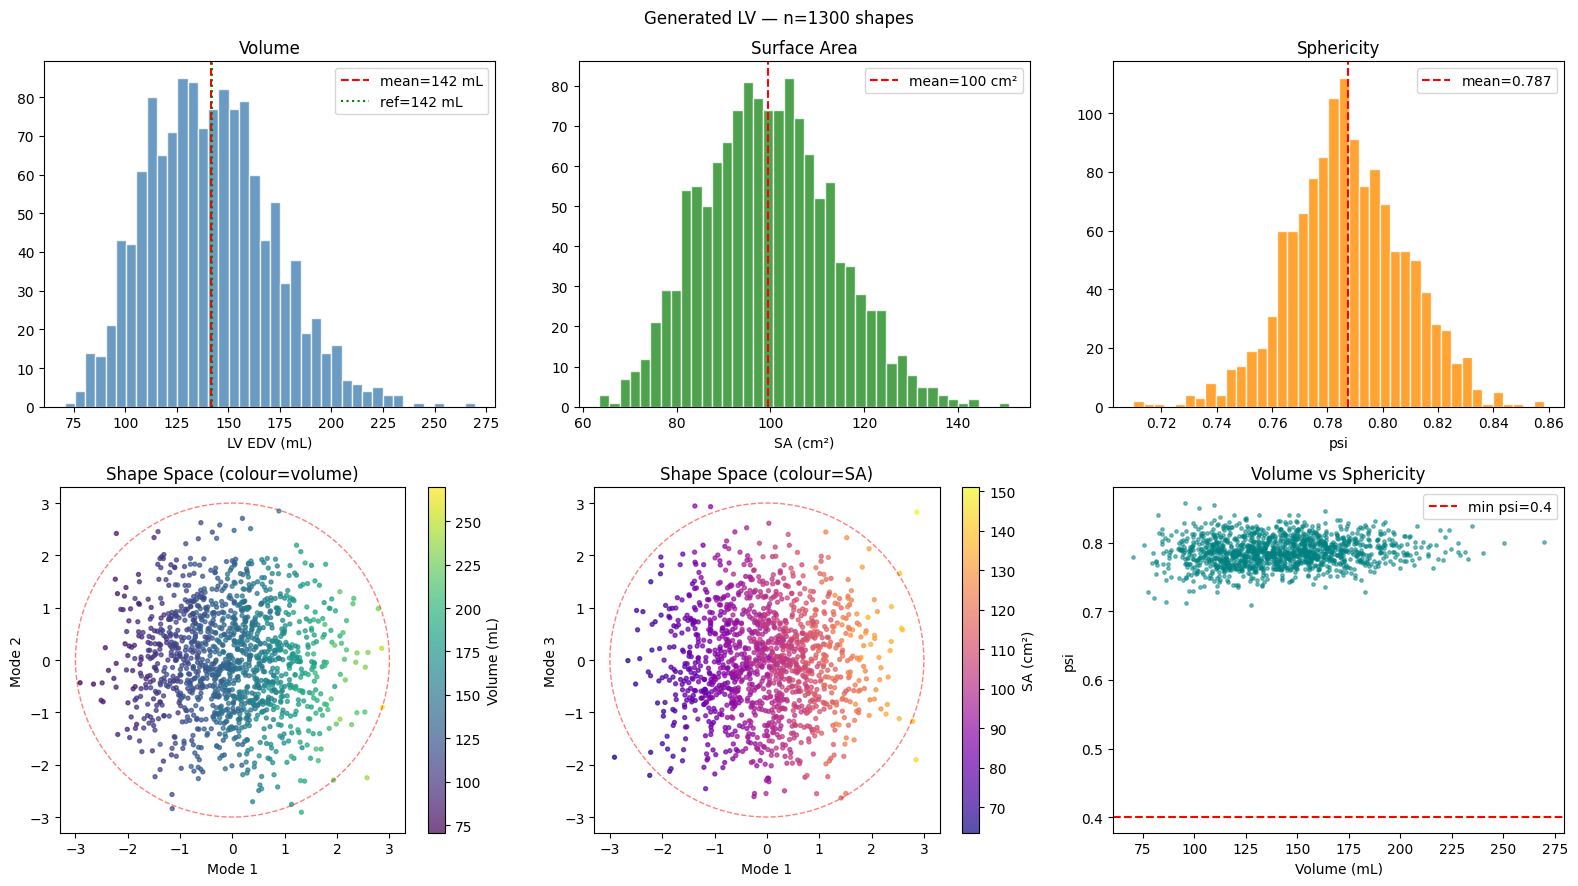

In [10]:
vols  = np.array([m['volume_ml']         for m in metadata])
sas   = np.array([m['surface_area_cm2']  for m in metadata])
psis  = np.array([m['sphericity']        for m in metadata])
b_acc = np.array([m['b']                 for m in metadata])

print(f'Vol  (mL) mean={vols.mean():.1f}  std={vols.std():.1f}  min={vols.min():.1f}  max={vols.max():.1f}')
print(f'SA (cm²)  mean={sas.mean():.1f}   std={sas.std():.1f}  min={sas.min():.1f}  max={sas.max():.1f}')
print(f'psi       mean={psis.mean():.3f}  std={psis.std():.3f}  min={psis.min():.3f}  max={psis.max():.3f}')
print(f'Reference mean LVEDV : {REFERENCE_MEAN_VOL_ML:.0f} mL')
print(f'Generated mean LVEDV : {vols.mean():.1f} mL')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
theta = np.linspace(0, 2*np.pi, 300)

ax = axes[0, 0]
ax.hist(vols, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(vols.mean(), color='r', ls='--', label=f'mean={vols.mean():.0f} mL')
ax.axvline(REFERENCE_MEAN_VOL_ML, color='g', ls=':', label=f'ref={REFERENCE_MEAN_VOL_ML:.0f} mL')
ax.set_xlabel('LV EDV (mL)'); ax.set_title('Volume'); ax.legend()

ax = axes[0, 1]
ax.hist(sas, bins=40, color='forestgreen', alpha=0.8, edgecolor='white')
ax.axvline(sas.mean(), color='r', ls='--', label=f'mean={sas.mean():.0f} cm²')
ax.set_xlabel('SA (cm²)'); ax.set_title('Surface Area'); ax.legend()

ax = axes[0, 2]
ax.hist(psis, bins=40, color='darkorange', alpha=0.8, edgecolor='white')
ax.axvline(psis.mean(), color='r', ls='--', label=f'mean={psis.mean():.3f}')
ax.set_xlabel('psi'); ax.set_title('Sphericity'); ax.legend()

ax = axes[1, 0]
sc = ax.scatter(b_acc[:, 0] / sigmas_eff[0], b_acc[:, 1] / sigmas_eff[1],
                c=vols, cmap='viridis', s=8, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Volume (mL)')
ax.plot(3*np.cos(theta), 3*np.sin(theta), 'r--', lw=1, alpha=0.5)
ax.set_xlabel('Mode 1'); ax.set_ylabel('Mode 2')
ax.set_title('Shape Space (colour=volume)'); ax.set_aspect('equal')

ax = axes[1, 1]
sc2 = ax.scatter(b_acc[:, 0] / sigmas_eff[0], b_acc[:, 2] / sigmas_eff[2],
                 c=sas, cmap='plasma', s=8, alpha=0.7)
plt.colorbar(sc2, ax=ax, label='SA (cm²)')
ax.plot(3*np.cos(theta), 3*np.sin(theta), 'r--', lw=1, alpha=0.5)
ax.set_xlabel('Mode 1'); ax.set_ylabel('Mode 3')
ax.set_title('Shape Space (colour=SA)'); ax.set_aspect('equal')

ax = axes[1, 2]
ax.scatter(vols, psis, s=6, alpha=0.5, color='teal')
ax.axhline(SPHER_MIN, color='r', ls='--', label=f'min psi={SPHER_MIN}')
ax.set_xlabel('Volume (mL)'); ax.set_ylabel('psi')
ax.set_title('Volume vs Sphericity'); ax.legend()

plt.suptitle(f'Generated LV — n={len(metadata)} shapes', fontsize=12)
plt.tight_layout(); plt.show()

## 5b. Pathology Simulation

Normal        V=142.0 mL  SA=100.0 cm²  psi=0.789
DCM           V=248.7 mL  SA=145.7 cm²  psi=0.787
HCM           V=74.2 mL  SA=66.9 cm²  psi=0.765
Post-MI       V=137.2 mL  SA=98.6 cm²  psi=0.782


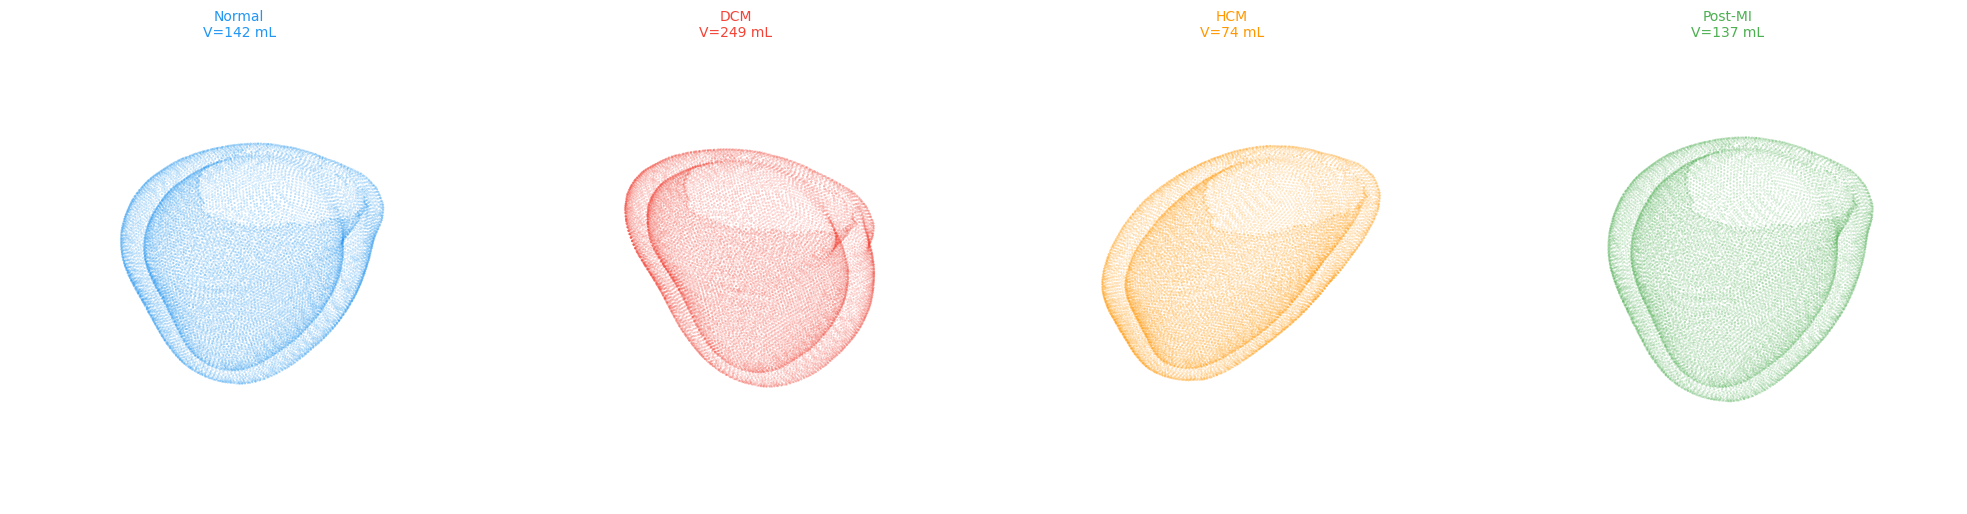

In [11]:
sigmas_full = np.sqrt(lambdas)

b_normal = np.zeros(100)
b_dcm    = np.zeros(100); b_dcm[0] = +3.5*sigmas_full[0]; b_dcm[1] = +3.0*sigmas_full[1]
b_hcm    = np.zeros(100); b_hcm[0] = -3.0*sigmas_full[0]; b_hcm[1] = -2.5*sigmas_full[1]
b_mi     = np.zeros(100); b_mi[3]  = +3.5*sigmas_full[3]; b_mi[4]  = +2.5*sigmas_full[4]

cases = {'Normal': b_normal, 'DCM': b_dcm, 'HCM': b_hcm, 'Post-MI': b_mi}

case_metrics = {}
for label, b in cases.items():
    pts = mesh_points_from_latent(b)
    vol, sa, psi = compute_mesh_quality_fast(pts)
    case_metrics[label] = dict(pts=pts, vol_ml=vol/SCALE_VOL, sa_cm2=sa/SCALE_SA, psi=psi)
    print(f'{label:<12}  V={vol/SCALE_VOL:.1f} mL  SA={sa/SCALE_SA:.1f} cm²  psi={psi:.3f}')

COLORS = ['#2196F3', '#F44336', '#FF9800', '#4CAF50']
fig = plt.figure(figsize=(20, 5))
for col, (label, m) in enumerate(case_metrics.items()):
    ax = fig.add_subplot(1, 4, col+1, projection='3d')
    pts = m['pts']
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=0.08, alpha=0.3, color=COLORS[col])
    ax.set_title(f"{label}\nV={m['vol_ml']:.0f} mL", fontsize=10, color=COLORS[col])
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 6. Extract Short-Axis Slice Stack

In [12]:
N_SLICES        = 10
SLICE_THICKNESS = 8.0
SLICE_SPACING   = 10.0

def extract_sax_stack(points, n_slices=N_SLICES,
                      thickness_mm=SLICE_THICKNESS, spacing_mm=SLICE_SPACING):
    z_min, z_max = points[:, 2].min(), points[:, 2].max()
    lv_height    = z_max - z_min
    stack_start  = z_min + (lv_height - spacing_mm*(n_slices-1)) / 2.0
    z_centres    = stack_start + np.arange(n_slices) * spacing_mm
    half = thickness_mm / 2.0
    all_xyz, all_ids = [], []
    valid_mask = np.zeros(n_slices, dtype=bool)
    for si, zc in enumerate(z_centres):
        mask = np.abs(points[:, 2] - zc) <= half
        if mask.sum() == 0: continue
        valid_mask[si] = True
        xy    = points[mask, :2]
        znorm = np.full(len(xy), (zc - z_min) / (lv_height + 1e-8))
        all_xyz.append(np.column_stack([xy, znorm]))
        all_ids.append(np.full(len(xy), si, dtype=np.int64))
    if not all_xyz:
        return np.empty((0,3)), np.empty(0, dtype=np.int64), z_centres, valid_mask
    return np.vstack(all_xyz), np.concatenate(all_ids), z_centres, valid_mask

for i in range(min(5, num_samples)):
    pts, _ = load_vtk_points(f'generated_meshes/mesh_{i:04d}.vtk')
    xyz, ids, _, vm = extract_sax_stack(pts)
    print(f'mesh {i}: {vm.sum()} valid slices, {len(xyz)} nodes')

mesh 0: 10 valid slices, 17380 nodes
mesh 1: 10 valid slices, 17298 nodes
mesh 2: 10 valid slices, 17073 nodes
mesh 3: 10 valid slices, 17846 nodes
mesh 4: 10 valid slices, 16353 nodes


## 7. Augmentation

In [13]:
%mkdir dataset
%ls
!cp -r generated_meshes dataset/

dataset/  generated_meshes/  Statistical-Shape-Model/


In [ ]:
!zip -r dataset/generated_meshes.zip generated_meshes

  adding: generated_meshes/ (stored 0%)
  adding: generated_meshes/mesh_0518.vtk (deflated 67%)
  adding: generated_meshes/mesh_0381.vtk (deflated 67%)
  adding: generated_meshes/mesh_1080.vtk (deflated 67%)
  adding: generated_meshes/mesh_1053.vtk (deflated 67%)
  adding: generated_meshes/mesh_0838.vtk (deflated 67%)
  adding: generated_meshes/mesh_0243.vtk (deflated 67%)
  adding: generated_meshes/mesh_1175.vtk (deflated 67%)
  adding: generated_meshes/mesh_0822.vtk (deflated 67%)
  adding: generated_meshes/mesh_0720.vtk (deflated 67%)
  adding: generated_meshes/mesh_1278.vtk (deflated 67%)
  adding: generated_meshes/mesh_0226.vtk (deflated 67%)
  adding: generated_meshes/mesh_0760.vtk (deflated 67%)
  adding: generated_meshes/mesh_1024.vtk (deflated 67%)
  adding: generated_meshes/mesh_0060.vtk (deflated 67%)
  adding: generated_meshes/mesh_0259.vtk (deflated 67%)
  adding: generated_meshes/mesh_0339.vtk (deflated 67%)
  adding: generated_meshes/mesh_0860.vtk (deflated 67%)
  adding

## 8. PyTorch Geometric Dataset

In [ ]:
def compute_vertex_normals_np(verts, faces):
    """Compute smooth vertex normals from mesh."""
    v0, v1, v2 = verts[faces[:, 0]], verts[faces[:, 1]], verts[faces[:, 2]]
    fn = np.cross(v1 - v0, v2 - v0)
    vn = np.zeros_like(verts)
    for i in range(3):
        np.add.at(vn, faces[:, i], fn)
    norms = np.linalg.norm(vn, axis=1, keepdims=True).clip(min=1e-8)
    return (vn / norms).astype(np.float32)


def generate_epi_variable_offset(endo_verts, endo_faces,
                                  base_offset=10.0, apex_offset=5.0,
                                  noise_std=0.5, rng=None):
    """Generate epicardium by offsetting endocardium outward along normals."""
    if rng is None:
        rng = np.random.default_rng()
    normals = compute_vertex_normals_np(endo_verts, endo_faces)
    z = endo_verts[:, 2]
    z_norm = (z.max() - z) / (z.max() - z.min() + 1e-8)
    offset = base_offset + (apex_offset - base_offset) * z_norm
    offset += rng.normal(0, noise_std, len(offset)).astype(np.float32)
    offset = np.clip(offset, apex_offset * 0.5, base_offset * 1.5)
    epi_verts = endo_verts + normals * offset[:, None]
    epi_faces = endo_faces[:, [0, 2, 1]]   # flip winding for outward normals
    return epi_verts.astype(np.float32), epi_faces


def robust_tissue_labels(radii):
    """KMeans clustering to distinguish endo (inner) from epi (outer)."""
    from sklearn.cluster import KMeans
    n = len(radii)
    if n < 6:
        return (radii >= np.median(radii)).astype(np.float32)
    try:
        km = KMeans(n_clusters=2, n_init=5, random_state=42, max_iter=100)
        labels = km.fit_predict(radii.reshape(-1, 1))
        # Ensure label 0 = endo (smaller radius), label 1 = epi
        if km.cluster_centers_[0, 0] > km.cluster_centers_[1, 0]:
            labels = 1 - labels
        return labels.astype(np.float32)
    except Exception:
        return (radii >= np.median(radii)).astype(np.float32)


def angular_order(xy):
    """Sort 2D points counterclockwise from centroid."""
    c = xy.mean(0)
    return np.argsort(np.arctan2(xy[:, 1] - c[1], xy[:, 0] - c[0]))


def extract_sax_contours(points, n_slices=N_SLICES, thick=SLICE_THICKNESS,
                         space=SLICE_SPACING, pts_per_ring=120):
    # pts_per_ring=120: 10 slices × 2 rings × 120 pts ≈ 2400 points
    # matches the old working cache format (~2354 pts)
    z_min, z_max = points[:, 2].min(), points[:, 2].max()
    start = z_min + (z_max - z_min - space * (n_slices - 1)) / 2.0
    z_ctrs = (start + np.arange(n_slices) * space).astype(np.float32)
    half = thick / 2.0
    all_xyz, all_tissue, all_sids = [], [], []
    valid_mask = np.zeros(n_slices, dtype=bool)

    for si, zc in enumerate(z_ctrs):
        mask = np.abs(points[:, 2] - zc) <= half
        if mask.sum() < 8:
            continue
        xy = points[mask, :2]
        c = xy.mean(0)
        r = np.linalg.norm(xy - c, axis=1).astype(np.float32)
        t = robust_tissue_labels(r)

        has_pts = False
        for label in [0.0, 1.0]:
            ring_xy = xy[t == label]
            if len(ring_xy) < 3:
                continue
            idx = angular_order(ring_xy)
            step = max(1, len(ring_xy) // pts_per_ring)
            sel = idx[::step][:pts_per_ring]
            ring = ring_xy[sel]
            z_col = np.full(len(ring), zc, dtype=np.float32)
            all_xyz.append(np.column_stack([ring, z_col]).astype(np.float32))
            all_tissue.append(np.full(len(ring), label, dtype=np.float32))
            all_sids.append(np.full(len(ring), si, dtype=np.int64))
            has_pts = True

        if has_pts:
            valid_mask[si] = True

    if not all_xyz:
        return (np.empty((0, 3), np.float32), np.empty(0, np.float32),
                np.empty(0, np.int64), z_ctrs, valid_mask)
    return (np.vstack(all_xyz).astype(np.float32),
            np.concatenate(all_tissue),
            np.concatenate(all_sids),
            z_ctrs, valid_mask)


def normalize_xyz(xyz, centroid=None, scale=None):
    """Normalize 3D coords: center at centroid, scale by mean XY radius."""
    out = xyz.copy().astype(np.float32)
    if centroid is None:
        cxy = out[:, :2].mean(0)
        centroid = np.array([cxy[0], cxy[1], out[:, 2].mean()], dtype=np.float32)
    if scale is None:
        scale = float(max(np.linalg.norm(out[:, :2] - centroid[:2], axis=1).mean(), 1e-3))
    out -= centroid
    out /= scale
    return out, centroid, float(scale)


def precompute_geometry(mesh_idx, B_matrix):
    """Build cached geometry matching build-lv-cache exactly."""
    path = f'generated_meshes/mesh_{mesh_idx:04d}.vtk'
    rng = np.random.default_rng(mesh_idx)

    pts, polydata = load_vtk_points(path)

    # FIX 1: Use TEMPLATE_FACES (already triangulated via vtkTriangleFilter).
    # Raw polydata cells are NOT pure triangles — extracting first 3 IDs from
    # each cell gives 43840 malformed faces instead of the correct 18291
    # triangles, and breaks trimesh occupancy computation.
    endo_f = TEMPLATE_FACES.astype(np.int64)
    endo_v = pts.copy()

    # Generate synthetic epicardium from endocardium
    epi_v, epi_f = generate_epi_variable_offset(
        endo_v, endo_f,
        base_offset=10.0, apex_offset=5.0, noise_std=0.5, rng=rng)

    # Extract SAX contours from combined endo+epi
    all_pts = np.vstack([endo_v, epi_v])
    xyz, tissue, sids, z_ctrs, valid_mask = extract_sax_contours(all_pts)

    # Fallback if no contours extracted
    if len(xyz) == 0:
        take = min(256, len(all_pts))
        sel = rng.choice(len(all_pts), take, replace=False)
        xyz = all_pts[sel].astype(np.float32)
        tissue = np.zeros(take, dtype=np.float32)
        sids = np.zeros(take, dtype=np.int64)
        z_ctrs = np.zeros(N_SLICES, dtype=np.float32)
        valid_mask = np.zeros(N_SLICES, dtype=bool)

    # Normalize consistently
    xyz_n, centroid, scale = normalize_xyz(xyz)
    endo_vn, _, _ = normalize_xyz(endo_v, centroid, scale)
    epi_vn, _, _ = normalize_xyz(epi_v, centroid, scale)
    z_ctrs_n = (z_ctrs - centroid[2]) / scale

    # Stack contour with tissue label
    contour = np.column_stack([xyz_n, tissue]).astype(np.float32)

    # Pre-compute occupancy (expensive, done once here)
    n_query = 2048
    surface_std = 2.0 / scale
    n_surf = int(n_query * 0.4)
    n_rand = n_query - 2 * n_surf

    e_pts = endo_vn[rng.integers(0, len(endo_vn), n_surf)] + \
            rng.normal(0, surface_std, (n_surf, 3)).astype(np.float32)
    p_pts = epi_vn[rng.integers(0, len(epi_vn), n_surf)] + \
            rng.normal(0, surface_std, (n_surf, 3)).astype(np.float32)

    all_vn = np.vstack([endo_vn, epi_vn])
    lo, hi = all_vn.min(0) - 0.2, all_vn.max(0) + 0.2
    rand_pts = rng.uniform(lo, hi, (n_rand, 3)).astype(np.float32)

    query = np.vstack([e_pts, p_pts, rand_pts]).astype(np.float32)

    endo_mesh = trimesh.Trimesh(endo_vn, endo_f, process=False)
    epi_mesh = trimesh.Trimesh(epi_vn, epi_f, process=False)
    endo_occ = endo_mesh.contains(query).astype(np.float32)
    epi_occ = epi_mesh.contains(query).astype(np.float32)

    return dict(
        contour       = contour,
        slice_ids     = sids.astype(np.int64),
        slice_z       = z_ctrs_n.astype(np.float32),
        slice_z_mask  = valid_mask.astype(np.bool_),
        endo_vertices = endo_vn.astype(np.float32),
        endo_faces    = endo_f.astype(np.int32),
        epi_vertices  = epi_vn.astype(np.float32),
        epi_faces     = epi_f.astype(np.int32),
        scale         = np.float32(scale),
        centroid      = centroid.astype(np.float32),
        query         = query.astype(np.float32),
        endo_occ      = endo_occ.astype(np.float32),
        epi_occ       = epi_occ.astype(np.float32),
    )


# Build cache — wipe any old bad files first
cache_dir = 'occupancy_cache'
import shutil
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
os.makedirs(cache_dir)

print('Building occupancy cache...')
errors = []
for i in tqdm(range(num_samples), desc='Caching geometry'):
    try:
        d = precompute_geometry(i, B)
        np.savez_compressed(f'{cache_dir}/sample_{i:04d}.npz', **d)
    except Exception as e:
        errors.append((i, str(e)))
        print(f'  ⚠ mesh {i}: {e}')

n_built = len(list(Path(cache_dir).glob('sample_*.npz')))
print(f'✅ Cache built: {n_built} files  |  errors: {len(errors)}')

# Spot-check
d0 = np.load(f'{cache_dir}/sample_0000.npz')
print(f'\nQuick check sample_0000:')
print(f'  contour     : {d0["contour"].shape}   (expect ~2400, 4)')
print(f'  endo_faces  : {d0["endo_faces"].shape}  (expect ~18291, 3 — triangulated)')
print(f'  epi_faces   : {d0["epi_faces"].shape}   (same as endo, winding flipped)')
print(f'  tissue      : {np.unique(d0["contour"][:, 3])}  (expect [0. 1.])')
print(f'  endo_occ    : {d0["endo_occ"].mean()*100:.1f}%  (expect ~20-25%)')
print(f'  epi_occ     : {d0["epi_occ"].mean()*100:.1f}%  (expect ~60-70%)')
print(f'  valid_slices: {d0["slice_z_mask"].sum()} / 10')

# Build PyG dataset from corrected cache
def vtk_edges(polydata):
    edges = set()
    for i in range(polydata.GetNumberOfCells()):
        cell = polydata.GetCell(i)
        ids = [cell.GetPointId(j) for j in range(cell.GetNumberOfPoints())]
        for k in range(len(ids)):
            a, b_ = ids[k], ids[(k+1) % len(ids)]
            edges.add((min(a, b_), max(a, b_)))
    ei = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
    return torch.cat([ei, ei.flip(0)], dim=1)


dataset = []
for i in tqdm(range(num_samples), desc='Building PyG dataset'):
    d = np.load(f'{cache_dir}/sample_{i:04d}.npz')
    path = f'generated_meshes/mesh_{i:04d}.vtk'
    _, polydata = load_vtk_points(path)

    sample = Data(
        x              = torch.tensor(d['contour'],      dtype=torch.float),
        slice_id       = torch.tensor(d['slice_ids'],    dtype=torch.long),
        edge_index     = vtk_edges(polydata),
        y              = torch.tensor(d['endo_vertices'], dtype=torch.float),
        b              = torch.tensor(B[i],              dtype=torch.float),
        num_nodes      = len(d['contour']),
        n_slices       = int(d['slice_z_mask'].sum()),
        query_points   = torch.tensor(d['query'],        dtype=torch.float),
        endo_occupancy = torch.tensor(d['endo_occ'],     dtype=torch.float),
        epi_occupancy  = torch.tensor(d['epi_occ'],      dtype=torch.float),
        scale          = torch.tensor(d['scale'],        dtype=torch.float),
        centroid       = torch.tensor(d['centroid'],     dtype=torch.float),
    )
    dataset.append(sample)

print(f'\n✅ PyG dataset: {len(dataset)} samples')
ex = dataset[0]
print(f'  x (contour+tissue): {ex.x.shape}')
print(f'  y (endo_vertices):  {ex.y.shape}')
print(f'  query_points:       {ex.query_points.shape}')
print(f'  endo_occupancy:     {ex.endo_occupancy.shape}')
print(f'  epi_occupancy:      {ex.epi_occupancy.shape}')

## 9. Train / Val / Test Split

In [ ]:
train_data, tmp      = train_test_split(dataset, test_size=0.20, random_state=42)
val_data,  test_data = train_test_split(tmp,      test_size=0.50, random_state=42)

print(f'Train: {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}')

train_loader = PyGDataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = PyGDataLoader(val_data,   batch_size=16, shuffle=False)
test_loader  = PyGDataLoader(test_data,  batch_size=16, shuffle=False)
print('DataLoaders ready')

## 10. Dataset Statistics

In [ ]:
total_nodes = [d.x.shape[0]             for d in dataset]
n_valid     = [d.n_slices               for d in dataset]
edge_counts = [d.edge_index.shape[1]//2 for d in dataset]

print(f'Nodes/sample  mean={np.mean(total_nodes):.0f}  min={np.min(total_nodes)}  max={np.max(total_nodes)}')
print(f'Valid slices  mean={np.mean(n_valid):.1f}  min={np.min(n_valid)}  max={np.max(n_valid)}')
print(f'Mesh edges    mean={np.mean(edge_counts):.0f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(total_nodes, bins=30); axes[0].set_title('Nodes per sample')
axes[1].hist(n_valid, bins=range(1, N_SLICES+2)); axes[1].set_title('Valid slices per mesh')
d2_all = np.sum((B / np.sqrt(lambdas)) ** 2, axis=1)
axes[2].hist(d2_all, bins=40)
axes[2].axvline(mahal_thresh, color='r', ls='--', label=f'chi2 thresh ({mahal_thresh:.0f})')
axes[2].set_title('Mahalanobis d²'); axes[2].legend()
plt.tight_layout(); plt.show()